<a href="https://colab.research.google.com/github/Nurdaylight/A-Karpathy-repl/blob/main/14_01_2026__Makemore_from_zero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [236]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [237]:
import urllib.request

url = "https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt"
filename = 'names.txt'

with urllib.request.urlopen(url) as f:
    data = f.read().decode("utf-8")

words= data.splitlines()

In [238]:
#Creating characters and character to int maps
chars=sorted(set(".".join(words)))
itos = {i:j for i,j in enumerate(chars)}
stoi = {j:i for i,j in enumerate(chars)}

In [261]:
#Creating train dev test data.
import random
random.seed(42)
random.shuffle(words)
n1=int(len(words)*0.8)
n2=int(len(words)*0.9)
context=4
def data_prep(data,context_size):
  X=[]
  Y=[]
  for name in data:
    name="."*context_size+name+"."
    name=[stoi[a] for a in name]
    x =[name[i:i+context_size] for i in range(len(name)) if i+context_size<len(name)]
    y =[name[i+context_size] for i in range(len(name)) if i+context_size<len(name)]

    X+=x
    Y+=y
  return torch.tensor(X) ,torch.tensor(Y)
X_tr, Y_tr =data_prep(words[:n1],context)
X_dev, Y_dev =data_prep(words[n1:n2],context)


In [262]:
# create parameters
emb_dims=3
nrml=0.1
L1_len=100
lr=0.1
C=torch.randn(27,emb_dims)*nrml
W1=torch.randn(emb_dims*context,L1_len)*nrml
b1=torch.zeros(L1_len)
W2=torch.randn(L1_len,27)*nrml
b2=torch.zeros(27)
parameters=[C,W1,b1,W2,b2]
for p in parameters:
  p.requires_grad=True



In [263]:
#now create the model:
for i in range(30000):
  ids= torch.randint(0,len(X_tr), (32,))
  h = torch.tanh(C[X_tr[ids]].view(len(X_tr[ids]),-1)@W1 +b1)
  logits= h@W2+b2
  loss=F.cross_entropy(logits,Y_tr[ids])

  for p in parameters:
    p.grad = None

  loss.backward()

  for p in parameters:
    p.data += -lr * p.grad if i < 10000 else -lr*0.08 * p.grad
  if i % 100 == 0:
    print(loss)

tensor(3.2923, grad_fn=<NllLossBackward0>)
tensor(2.8855, grad_fn=<NllLossBackward0>)
tensor(2.7775, grad_fn=<NllLossBackward0>)
tensor(2.6043, grad_fn=<NllLossBackward0>)
tensor(2.7830, grad_fn=<NllLossBackward0>)
tensor(2.1446, grad_fn=<NllLossBackward0>)
tensor(2.3527, grad_fn=<NllLossBackward0>)
tensor(2.3170, grad_fn=<NllLossBackward0>)
tensor(2.5725, grad_fn=<NllLossBackward0>)
tensor(2.8055, grad_fn=<NllLossBackward0>)
tensor(2.4796, grad_fn=<NllLossBackward0>)
tensor(2.5707, grad_fn=<NllLossBackward0>)
tensor(2.1291, grad_fn=<NllLossBackward0>)
tensor(2.4885, grad_fn=<NllLossBackward0>)
tensor(2.5267, grad_fn=<NllLossBackward0>)
tensor(2.2306, grad_fn=<NllLossBackward0>)
tensor(2.2595, grad_fn=<NllLossBackward0>)
tensor(2.4304, grad_fn=<NllLossBackward0>)
tensor(2.4332, grad_fn=<NllLossBackward0>)
tensor(2.4512, grad_fn=<NllLossBackward0>)
tensor(2.2056, grad_fn=<NllLossBackward0>)
tensor(2.5025, grad_fn=<NllLossBackward0>)
tensor(2.0794, grad_fn=<NllLossBackward0>)
tensor(2.45

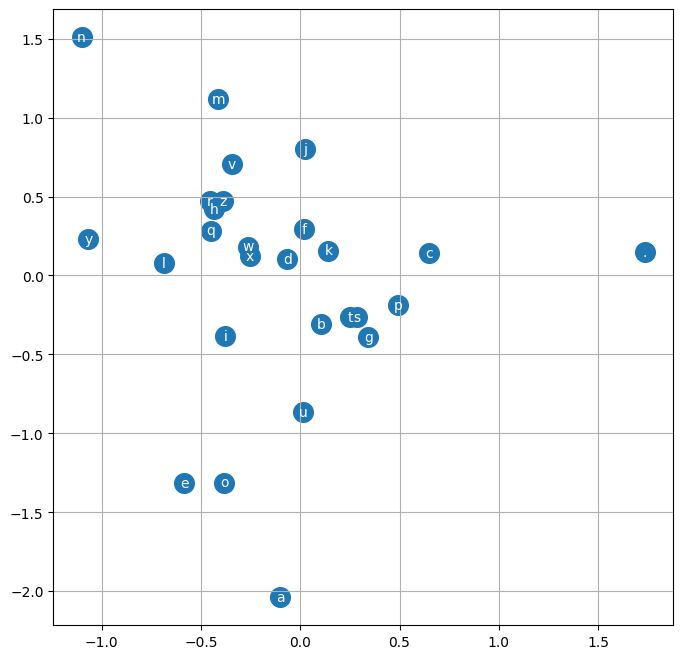

In [264]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,1].data, C[:,2].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,1].item(), C[i,2].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

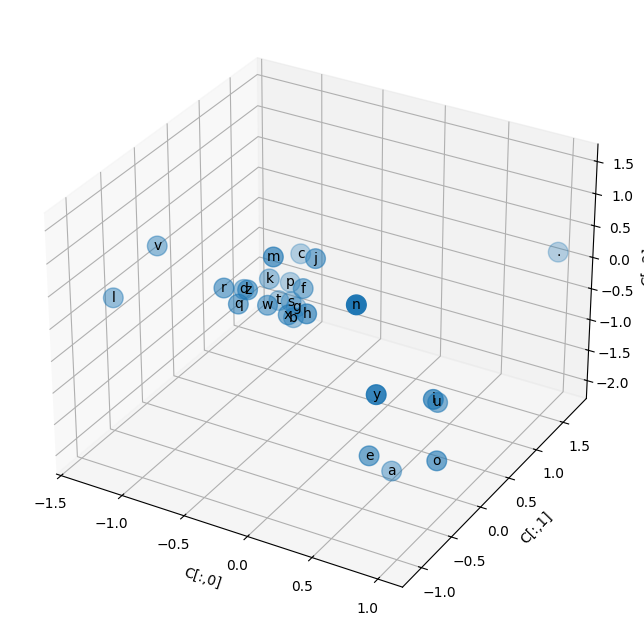

In [265]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    C[:, 0].data,
    C[:, 1].data,
    C[:, 2].data,
    s=200
)

for i in range(C.shape[0]):
    ax.text(
        C[i, 0].item(),
        C[i, 1].item(),
        C[i, 2].item(),
        itos[i],
        ha="center",
        va="center",
        color="black"
    )

ax.set_xlabel("C[:,0]")
ax.set_ylabel("C[:,1]")
ax.set_zlabel("C[:,2]")

plt.show()

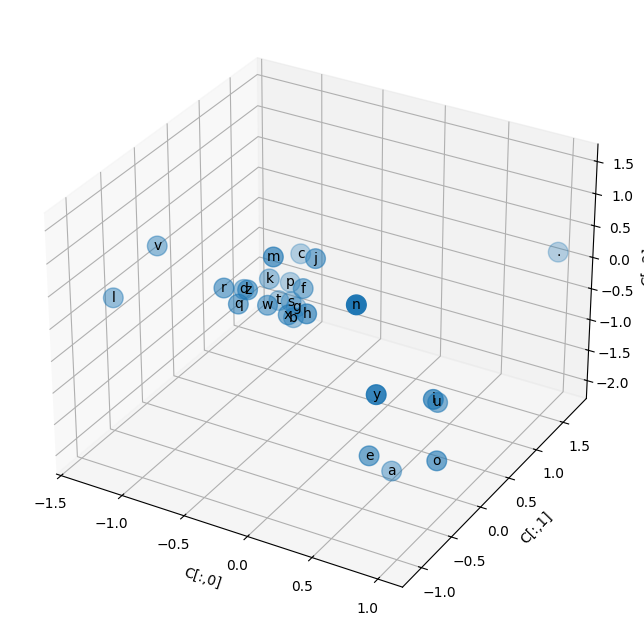

In [266]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    C[:, 0].data,
    C[:, 1].data,
    C[:, 2].data,
    s=200
)

for i in range(C.shape[0]):
    ax.text(
        C[i, 0].item(),
        C[i, 1].item(),
        C[i, 2].item(),
        itos[i],
        ha="center",
        va="center",
        color="black"
    )

ax.set_xlabel("C[:,0]")
ax.set_ylabel("C[:,1]")
ax.set_zlabel("C[:,2]")

plt.show()

In [160]:
W1.size()

torch.Size([6, 100])

In [165]:
(C[X_tr].reshape(len(X_tr),-1)@W1)+b1

RuntimeError: The size of tensor a (182762) must match the size of tensor b (6) at non-singleton dimension 0

In [267]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    bs = [0] * context # initialize with all ...
    while True:
      emb = C[torch.tensor([bs])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      bs = bs[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

careah.
amille.
khismish.
thty.
salana.
errahnen.
deliaht.
kaqei.
nerania.
chaiiv.
kaleig.
hham.
join.
qainn.
sroilea.
jadbi.
wazelo.
dearyni.
jameuniruan.
edde.
